## Load Model

In [1]:
import model
import torch
import pandas as pd
import seaborn as sns
import evaluate
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<Axes: xlabel='step', ylabel='value'>

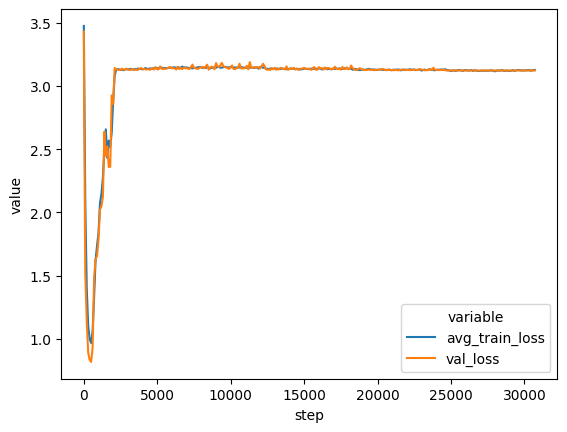

In [2]:
checkpoint = torch.load("models/MLC_data200k_nepoch_5.pt", map_location=DEVICE)
loss_data = pd.DataFrame(checkpoint["train_tracker"])
loss_data = pd.melt(loss_data, id_vars=['step'], value_vars=['avg_train_loss','val_loss'])
# plot train/val loss
sns.lineplot(data=loss_data, x='step', y='value', hue='variable')

In [5]:
# load model & batch
langs, train, val, net = model.load_model("models/MLC_data200k_nepoch_5.pt")
batch = next(iter(val))
# predict for batch:
preds = evaluate.predict(batch, net, langs, 20, eval_type="max")

print("True Labels/Predictions:\n-----------------------------------------")
for true, pred in zip(batch["yq"], preds):
    print(f"True: {" ".join(true)}\nPred: {" ".join(pred)}\n")

 Loading model that has completed (or started) 5 of 5 epochs
  batch size: 25
  number of steps: 30770
  best val loss achieved: inf
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
True Labels/Predictions:
-----------------------------------------
True: k g v
Pred: 

True: i j k
Pred: 

True: j n m
Pred: 

True: r g h i j
Pred: 

True: w p q r s
Pred: 

True: o p q e s t u
Pred: 

True: j l
Pred: 

True: m n o
Pred: 

True: q r y t v
Pred: 

True: l m n
Pred: 

True: j k l m n o p
Pred: 

True: y z q r
Pred: 

True: h i j k l m n
Pred: 

True: b c d r f g
Pred: 

True: r f g h j
Pred: 

True: a o k d e
Pred: 

True: i j k l m n
Pred: 

True: s t u v b x
Pred: 

True: l n o
Pred: 

True: g h i j k l
Pred: 

True: g v o y
Pred: 

True: r g
Pred: 

True: t u v b
Pred: 

True: g v o y z q l
Pred: 

True: q e s t u v w
Pred: 

